In [1]:
#Libraries 
import os
import time
import math
import numpy as np
import pandas as pd
import scipy
import scipy.signal as spsg
from scipy import stats
from scipy.io import loadmat
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cityblock
from data.labels_brain import reorder_matrix
from scipy.special import comb


random.seed(42)

In [2]:
# Read the data
data_path = "C:/Users/diego/Desktop/phase_coherance_consciousness/data"

#Load FC (Psilo and Placebo)
FC_LSD = loadmat(os.path.join(data_path, "avg_LSD_FC.mat"))["avg_LSD_FC_n"]
FC_PLA = loadmat(os.path.join(data_path, "avg_PL_FC.mat"))["avg_PL_FC_n"]

In [3]:
#Dfine Region Boundaries and Names (Same Lenght)
region_boundaries = [93, 177, 255, 308, 360, 412, 448, 462]
#region_names = ["Frontal", "Temporal", "Parietal", "Occipital", "Subcortical", "Cerebellum", "Brainstem", "Other"]

In [13]:
def Region_Heatmap(corr_matrix, 
                   region_boundaries, 
                   region_names=None, 
                   vmin=-1, 
                   vmax=1,
                   name='Brain Region Connectivity Heatmap'):
    """
    Create a simple heatmap visualization of brain region connectivity with highlighted boundaries.

    Parameters:
    - corr_matrix: NxN numpy array of correlations
    - region_boundaries: List of indices defining the boundaries of each region
                        (e.g., [93, 177, 255, ...] means region 1 is 0-92, region 2 is 93-176, etc.)
    - region_names: List of names for each region (optional)
    - vmin: Minimum value for color scaling (default: -1)
    - vmax: Maximum value for color scaling (default: 1)
    """

    N = corr_matrix.shape[0]
    
    # Create default region names if not provided
    num_regions = len(region_boundaries)
    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(num_regions)]
    elif len(region_names) != num_regions:
        raise ValueError("Number of region names must match the number of regions")
    

    fig = plt.figure(figsize=(8, 6))
    im = plt.imshow(corr_matrix, cmap="coolwarm", aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Correlation')
    
    boundaries = [0] + region_boundaries
    
    # boundary lines
    for b in boundaries:
        plt.axhline(y=b-0.5, color='black', linestyle='-', linewidth=1)
        plt.axvline(x=b-0.5, color='black', linestyle='-', linewidth=1)
    

    ytick_positions = []
    ytick_labels = []
    
    for i in range(len(boundaries)-1):
        start = boundaries[i]
        end = boundaries[i+1]
        center = (start + end - 1) / 2
        ytick_positions.append(center)
        ytick_labels.append(region_names[i])
    
    if boundaries[-1] < N:
        center = (boundaries[-1] + N - 1) / 2
        ytick_positions.append(center)
        ytick_labels.append("Other")
    

    plt.yticks(ytick_positions, ytick_labels)
    plt.xticks(ytick_positions, ytick_labels, rotation=45, ha='right')
    plt.title(name)
    plt.ylabel('Brain Regions')
    plt.tight_layout()
    
    return fig

In [14]:
def create_index_based_chord_diagram(correlation_matrix, region_boundaries, 
                                     region_names=None,
                                     mean=True, 
                                     threshold=0.01, 
                                     name="Brain Region Connectivity", 
                                     normalize=True, 
                                     min_opacity=0.3, 
                                     min_width=0.5):
    """
    Create a circular chord diagram for a brain correlation matrix based on index ranges.
    
    Parameters:
    - correlation_matrix: NxN numpy array of correlations (values between -1 and 1)
    - region_boundaries: List of indices defining the boundaries of each region
                        (e.g., [93, 177, 255, ...] means region 1 is 0-92, region 2 is 93-176, etc.)
    - region_names: List of names for each region (optional)
    - mean: If True, calculates the connectivity between regions based on the average,
           otherwise uses median (False)
    - threshold: Minimum absolute correlation strength to display chord (default: 0.01)
    - name: Title for the plot
    - normalize: Whether to normalize the correlation values for better visualization
    """
    
    N = correlation_matrix.shape[0]
    
    # Ensure the correlation matrix is square
    if correlation_matrix.shape[0] != correlation_matrix.shape[1]:
        raise ValueError("Correlation matrix must be square")
    
    # Ensure the matrix size is adequate for the specified regions
    if region_boundaries[-1] > N:
        raise ValueError(f"Region boundary {region_boundaries[-1]} exceeds matrix size {N}")
    
    num_regions = len(region_boundaries)
    region_indices = [0] + region_boundaries
    
    # Create default region names if not provided
    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(num_regions)]
    elif len(region_names) != num_regions:
        raise ValueError("Number of region names must match the number of regions")
    
    # Calculate group connectivity (average/median correlation between regions)
    group_connectivity = np.zeros((num_regions, num_regions))
    
    # Calculate region sizes (number of observations in each region)
    region_sizes = []
    for i in range(num_regions):
        start_i = region_indices[i]
        end_i = region_indices[i+1] if i < num_regions-1 else N
        region_sizes.append(end_i - start_i)
    
    # Calculate the arc lengths proportional to region sizes
    total_size = sum(region_sizes)
    arc_lengths = np.array(region_sizes) / total_size * 2 * np.pi
    
    for i in range(num_regions):
        start_i = region_indices[i]
        end_i = region_indices[i+1] if i < num_regions-1 else N
        
        for j in range(num_regions):
            start_j = region_indices[j]
            end_j = region_indices[j+1] if j < num_regions-1 else N
            
            # Extract submatrix and calculate the average/median connectivity
            submatrix = correlation_matrix[start_i:end_i, start_j:end_j]
            
            if mean:
                if i == j:
                    mask = ~np.eye(submatrix.shape[0], dtype=bool)
                    group_connectivity[i, j] = np.mean(submatrix[mask]) if mask.sum() > 0 else 0
                else:
                    group_connectivity[i, j] = np.mean(submatrix)
            else:
                if i == j:
                    mask = ~np.eye(submatrix.shape[0], dtype=bool)
                    group_connectivity[i, j] = np.median(submatrix[mask]) if mask.sum() > 0 else 0
                else:
                    group_connectivity[i, j] = np.median(submatrix)
    
    # Normalize correlation values if requested - Scale to use full color range while preserving sign
    if normalize:
        # Excluding the diagonals
        mask = ~np.eye(num_regions, dtype=bool)
        max_corr = np.max(np.abs(group_connectivity[mask]))
        if max_corr > 0: 
            group_connectivity = group_connectivity / max_corr
            group_connectivity = np.clip(group_connectivity, -1, 1)
    
    #Diagram ----------------------------------------------------------------------------------------------------------------
    # Generate colors for regions
    cmap = plt.cm.viridis
    group_colors = cmap(np.linspace(0, 1, num_regions))[:, :3]

    fig, ax = plt.subplots(figsize=(10, 10))
    start_angles = np.cumsum(np.concatenate(([0], arc_lengths[:-1])))
    end_angles = start_angles + arc_lengths
    start_angles -= np.pi/2 
    end_angles -= np.pi/2
    inner_radius, outer_radius = 0.8, 1.0
    
    # Draw arcs for each region
    for i in range(num_regions):
        arc_theta = np.linspace(start_angles[i], end_angles[i], 50)    
        x_inner = inner_radius * np.cos(arc_theta)
        y_inner = inner_radius * np.sin(arc_theta)
        x_outer = outer_radius * np.cos(arc_theta)
        y_outer = outer_radius * np.sin(arc_theta)
        
        ax.fill(np.concatenate([x_inner, x_outer[::-1]]),
                np.concatenate([y_inner, y_outer[::-1]]),
                color=group_colors[i],
                alpha=0.7,
                edgecolor='none')
        
        # Position labels
        mid_angle = (start_angles[i] + end_angles[i]) / 2
        label_radius = 1.1
        label_x = label_radius * np.cos(mid_angle)
        label_y = label_radius * np.sin(mid_angle)
        
        if label_x > 0 and label_y > 0: 
            ha, va = 'left', 'bottom'
            rotation = mid_angle * 180/np.pi - 90
        elif label_x < 0 and label_y > 0:  
            ha, va = 'right', 'bottom'
            rotation = mid_angle * 180/np.pi + 90
        elif label_x < 0 and label_y < 0:  
            ha, va = 'right', 'top'
            rotation = mid_angle * 180/np.pi + 90
        else:  
            ha, va = 'left', 'top'
            rotation = mid_angle * 180/np.pi - 90
        

        ax.text(label_x, label_y, region_names[i],
                fontweight='bold',
                horizontalalignment=ha,
                verticalalignment=va,
                rotation=rotation)
    
    # Create a colormap for chords (blue to red) with more saturation
    blue_red_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_red', [(0, 'darkblue'), (0.45, 'blue'), (0.5, 'white'),
                (0.55, 'red'), (1, 'darkred')])
    
    # Draw chords
    chord_count = 0
    for i in range(num_regions):
        for j in range(i+1, num_regions):  # Only upper triangle to avoid duplicates
            correlation_value = group_connectivity[i, j]
            
            if abs(correlation_value) > threshold:
                chord_count += 1
                mid_angle_i = (start_angles[i] + end_angles[i]) / 2
                mid_angle_j = (start_angles[j] + end_angles[j]) / 2
                
                x1 = inner_radius * np.cos(mid_angle_i)
                y1 = inner_radius * np.sin(mid_angle_i)
                x2 = inner_radius * np.cos(mid_angle_j)
                y2 = inner_radius * np.sin(mid_angle_j)
                
                ctrl_radius = 0.5
                ctrl_x1 = ctrl_radius * np.cos(mid_angle_i)
                ctrl_y1 = ctrl_radius * np.sin(mid_angle_i)
                ctrl_x2 = ctrl_radius * np.cos(mid_angle_j)
                ctrl_y2 = ctrl_radius * np.sin(mid_angle_j)
                
                t = np.linspace(0, 1, 50)
                curve_x = (1-t)**3 * x1 + 3*(1-t)**2 * t * ctrl_x1 + 3*(1-t) * t**2 * ctrl_x2 + t**3 * x2
                curve_y = (1-t)**3 * y1 + 3*(1-t)**2 * t * ctrl_y1 + 3*(1-t) * t**2 * ctrl_y2 + t**3 * y2
                
                conn_strength = abs(correlation_value)
                # Ensure minimum line width
                line_width = max(min_width, min_width + 4 * conn_strength)
                
                # Map correlation value (-1 to 1) to colormap (0 to 1)
                color_val = (correlation_value + 1) / 2
                chord_color = blue_red_cmap(color_val)

                # Ensure minimum opacity
                alpha_val = max(min_opacity, min_opacity + 0.7 * conn_strength)
                
                ax.plot(curve_x, curve_y, color=chord_color, alpha=alpha_val, linewidth=line_width)
    
    # Add a colorbar correlation scale
    sm = plt.cm.ScalarMappable(cmap=blue_red_cmap, norm=plt.Normalize(-1, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.75, label='Correlation')
    
    # Add info text about normalization if applied
    if normalize:
        ax.text(0.78, 0.02, f"Values normalized (max abs corr: {max_corr:.3f})",
                transform=ax.transAxes, fontsize=8, va='top', ha='left')
    
    
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(name, fontsize=15, fontweight='bold')
    
    return fig

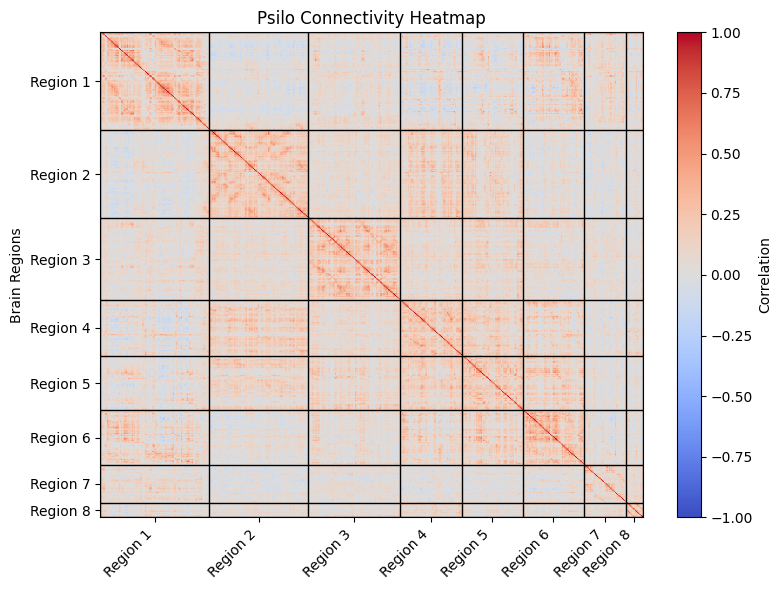

In [15]:
fig = Region_Heatmap(FC_LSD, region_boundaries,name="Psilo Connectivity Heatmap")
plt.show()

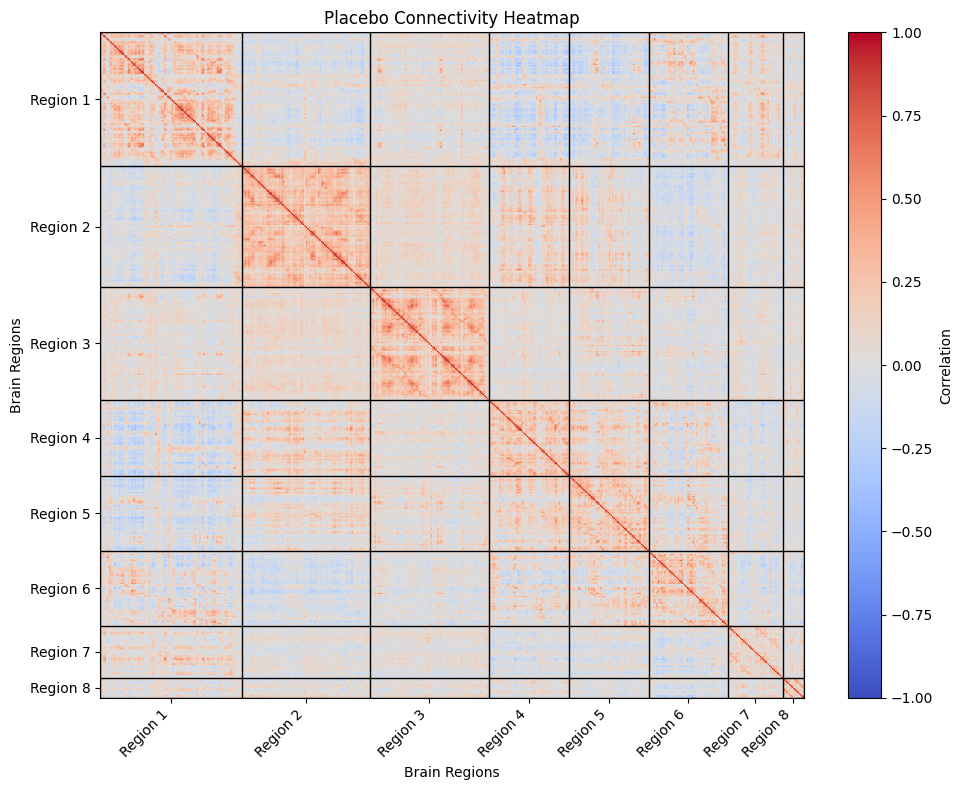

In [10]:
fig = Region_Heatmap(FC_PLA, region_boundaries,name="Placebo Connectivity Heatmap")
plt.show()

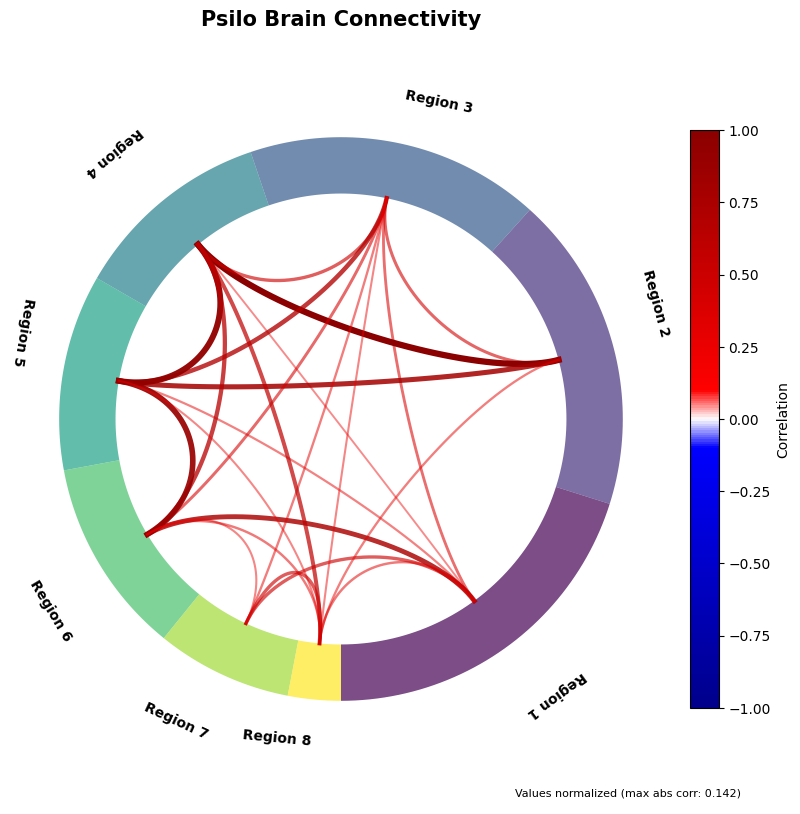

In [11]:
fig = create_index_based_chord_diagram(
    FC_LSD, 
    region_boundaries,
    threshold=0.2,
    mean=True,
    name="Psilo Brain Connectivity"
)
plt.show()



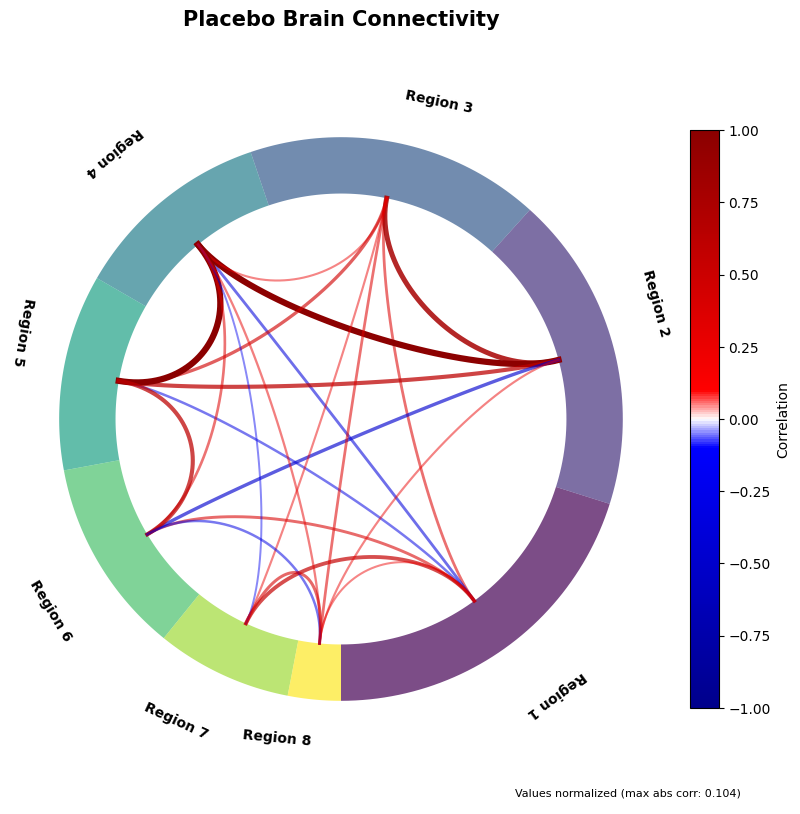

In [12]:
fig = create_index_based_chord_diagram(
    FC_PLA, 
    region_boundaries,
    threshold=0.2,
    mean=True,
    name="Placebo Brain Connectivity"
)
plt.show()

